In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, classification_report, ConfusionMatrixDisplay, RocCurveDisplay, precision_score, recall_score)
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42

In [2]:
df = pd.read_csv("data/credit_default.csv")

target_col = [c for c in df.columns if "default" in c.lower()][0]
df = df.rename(columns={target_col: "default"}).drop(columns=["ID"], errors="ignore")

# Undefined category codes in the dataset documentation
df["EDUCATION"] = df["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
df["MARRIAGE"] = df["MARRIAGE"].replace({0: 3})

print(df.shape)
print("default rate:", round(df["default"].mean(), 3))
print("missing values:", df.isna().sum().sum())

(30000, 24)
default rate: 0.221
missing values: 0


In [3]:
print(df.groupby("PAY_0")["default"].agg(["mean", "size"]).round(3))

        mean   size
PAY_0              
-2     0.132   2759
-1     0.168   5686
 0     0.128  14737
 1     0.339   3688
 2     0.691   2667
 3     0.758    322
 4     0.684     76
 5     0.500     26
 6     0.545     11
 7     0.778      9
 8     0.579     19


In [4]:
pay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

df["utilization"] = (df["BILL_AMT1"] / df["LIMIT_BAL"]).clip(-1, 2)
df["avg_pay_delay"] = df[pay_cols].mean(axis=1)

df[["utilization", "avg_pay_delay"]].describe().round(2)

,utilization,avg_pay_delay
count,30000.00,30000.00
mean,0.42,-0.18
std,0.40,0.98
min,-0.62,-2.00
25%,0.02,-0.83
50%,0.31,0.00
75%,0.83,0.00
max,2.00,6.00


In [5]:
y = df["default"]
X = df.drop(columns=["default"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print(X_train.shape, X_test.shape)
print("train default rate:", round(y_train.mean(), 3))
print("test default rate:", round(y_test.mean(), 3))

(24000, 25) (6000, 25)
train default rate: 0.221
test default rate: 0.221


In [6]:
models = {
    "logistic": Pipeline([
        ("scale", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
    ]),
    "random_forest": RandomForestClassifier(
        n_estimators=300, class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE
    ),
    "gradient_boosting": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc")
    cv_results[name] = scores.mean()
    print(f"{name}: AUC {scores.mean():.3f} (+/- {scores.std():.3f})")

logistic: AUC 0.727 (+/- 0.010)
random_forest: AUC 0.772 (+/- 0.005)
gradient_boosting: AUC 0.784 (+/- 0.004)


best model: gradient_boosting
test ROC-AUC: 0.778
test PR-AUC: 0.558
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.66      0.37      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.66      0.68      6000
weighted avg       0.80      0.82      0.80      6000



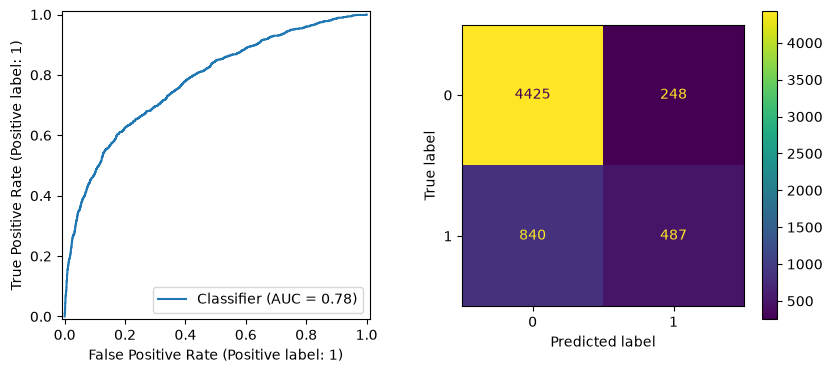

In [7]:
best_name = max(cv_results, key=cv_results.get)
best = models[best_name].fit(X_train, y_train)
proba = best.predict_proba(X_test)[:, 1]

print("best model:", best_name)
print("test ROC-AUC:", round(roc_auc_score(y_test, proba), 3))
print("test PR-AUC:", round(average_precision_score(y_test, proba), 3))
print(classification_report(y_test, (proba >= 0.5).astype(int)))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
RocCurveDisplay.from_predictions(y_test, proba, ax=ax[0])
ConfusionMatrixDisplay.from_predictions(y_test, (proba >= 0.5).astype(int), ax=ax[1])
plt.show()

In [8]:
rows = []
for t in [0.2, 0.3, 0.4, 0.5]:
    pred = (proba >= t).astype(int)
    rows.append({
        "threshold": t,
        "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred),
        "flagged_share": pred.mean(),
    })

pd.DataFrame(rows).round(3)

,threshold,precision,recall,flagged_share
0,0.2,0.424,0.666,0.348
1,0.3,0.546,0.538,0.218
2,0.4,0.618,0.427,0.153
3,0.5,0.663,0.367,0.122


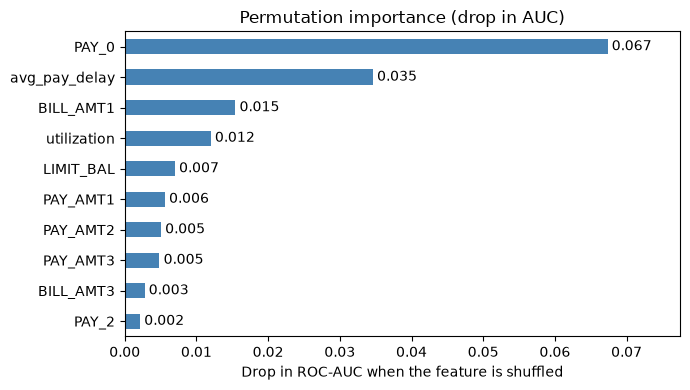

In [9]:
imp = permutation_importance(
    best, X_test, y_test, scoring="roc_auc", n_repeats=5,
    random_state=RANDOM_STATE, n_jobs=-1,
)

top = pd.Series(imp.importances_mean, index=X_test.columns).sort_values().tail(10)
plt.style.use("default")
fig, ax = plt.subplots(figsize=(7, 4), facecolor="white")
top.plot.barh(ax=ax, color="steelblue")
ax.bar_label(ax.containers[0], fmt="%.3f", padding=3)
ax.set_xlim(0, top.max() * 1.15)
ax.set_title("Permutation importance (drop in AUC)")
ax.set_xlabel("Drop in ROC-AUC when the feature is shuffled")
plt.tight_layout()
plt.show()